In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import imdb
import matplotlib.pyplot as plt

In [2]:
(train_data,train_labels),(test_data,test_labels)=imdb.load_data(num_words=10000)

In [14]:
def vectorize(sequences, dim=10000):
    result= np.zeros((len(sequences),dim))
    for i,seq in enumerate(sequences):
        result[i,seq]=1
    return result

In [15]:
x_train=vectorize(train_data)
x_test=vectorize(test_data)
y_train=np.array(train_labels).astype("float32")
y_test=np.array(test_labels).astype("float32")

In [20]:
model = Sequential()
model.add(Dense(16,input_shape=(10000,),activation="relu"))
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [21]:
model.compile(optimizer="adam",loss="mse",metrics=["mae"])

In [22]:
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 16)                160016    
                                                                 
 dense_5 (Dense)             (None, 16)                272       
                                                                 
 dense_6 (Dense)             (None, 1)                 17        
                                                                 
Total params: 160305 (626.19 KB)
Trainable params: 160305 (626.19 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [23]:
history=model.fit(x_train,y_train,epochs=25,validation_split=0.05,verbose=1)

Epoch 1/25
743/743 [==============================] - 6s 7ms/step - loss: 0.1033 - mae: 0.2153 - val_loss: 0.0879 - val_mae: 0.1612
Epoch 2/25
743/743 [==============================] - 4s 5ms/step - loss: 0.0548 - mae: 0.1103 - val_loss: 0.0925 - val_mae: 0.1488
Epoch 3/25
743/743 [==============================] - 4s 5ms/step - loss: 0.0412 - mae: 0.0820 - val_loss: 0.0957 - val_mae: 0.1416
Epoch 4/25
743/743 [==============================] - 4s 5ms/step - loss: 0.0316 - mae: 0.0620 - val_loss: 0.1047 - val_mae: 0.1402
Epoch 5/25
743/743 [==============================] - 4s 5ms/step - loss: 0.0259 - mae: 0.0489 - val_loss: 0.1060 - val_mae: 0.1381
Epoch 6/25
743/743 [==============================] - 4s 6ms/step - loss: 0.0207 - mae: 0.0387 - val_loss: 0.1157 - val_mae: 0.1419
Epoch 7/25
743/743 [==============================] - 4s 6ms/step - loss: 0.0177 - mae: 0.0315 - val_loss: 0.1134 - val_mae: 0.1379
Epoch 8/25
743/743 [==============================] - 4s 5ms/step - loss: 0.

<AxesSubplot:title={'center':'loss curve'}, xlabel='epochs', ylabel='loss'>

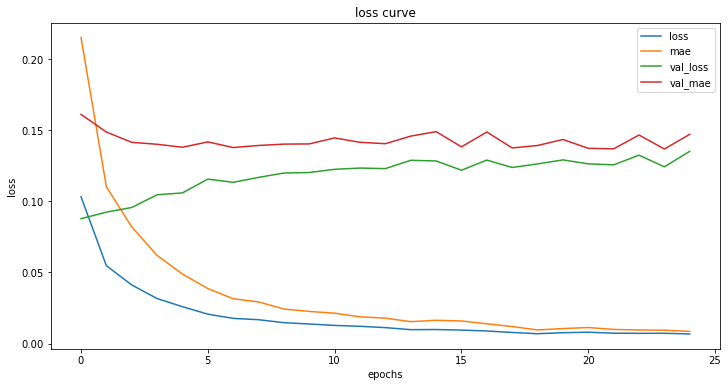

In [27]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(12,6),xlabel="epochs",ylabel="loss",title="loss curve")

In [28]:
y_pred=model.predict(x_test)
y_pred

782/782 [==============================] - 3s 3ms/step


array([[2.0146047e-06],
       [9.9999624e-01],
       [1.0000000e+00],
       ...,
       [5.6315739e-02],
       [1.4983097e-10],
       [5.5569362e-06]], dtype=float32)